# Memory Management

Memory allows agents to retain information across interactions. **Short-term memory** holds the current conversation context; **long-term memory** persists facts, preferences, and knowledge across sessions.

## Implementation with Flyte v2

This notebook reimplements the LangChain `ConversationBufferMemory` and LangGraph `InMemoryStore` patterns using **Flyte v2 primitives only**.

#### LangChain / LangGraph vs Flyte v2 — Key Differences

| Aspect | LangChain / LangGraph | Flyte v2 |
|--------|----------------------|----------|
| **Short-term memory** | `ConversationBufferMemory` (in-process, lost on restart) | Typed `ConversationMemory` dataclass — serialized by Flyte, survives retries |
| **Long-term memory** | LangGraph `InMemoryStore` (per-process, ephemeral) | Typed `UserProfile` dataclass passed via Flyte object store — durable |
| **Memory scope** | In-process only | Task outputs are stored in object storage; any downstream task can access them |
| **Observability** | Log parsing | Full memory state visible in Flyte UI as structured task output |
| **Serialization** | Automatic but opaque | Explicit typed dataclasses — inspectable, versionable |
| **Secrets** | `.env` / `os.environ` | `flyte.Secret` injected by cluster (no plaintext in code) |

### 1. Install dependencies

In [ ]:
!uv pip install 'flyte[tui]' anthropic

### Start the devbox

If you haven't already, install the flyte package with the command above, then launch the local cluster:

In [ ]:
!flyte start devbox

### 2. Store your API key

In [ ]:
!flyte create secret ANTHROPIC_API_KEY --value sk-...

### 3. Import dependencies and configure the TaskEnvironment

In [1]:
import os
from dataclasses import dataclass, field
from datetime import timedelta

from anthropic import AsyncAnthropic
import flyte

flyte.init_from_config()

_image = (
    flyte.Image.from_debian_base(name="memory-agent", python_version=(3, 12))
    .with_pip_packages("anthropic>=0.25.0")
)

memory_env = flyte.TaskEnvironment(
    name="memory_agent",
    image=_image,
    resources=flyte.Resources(cpu="1", memory="2Gi"),
    secrets=[
        flyte.Secret(key="ANTHROPIC_API_KEY", as_env_var="ANTHROPIC_API_KEY"),
    ],
)


### 4. Define the data models

**Short-term memory** (`ConversationMemory`) holds the current conversation thread as `list[dict[str, str]]` — the same format the Anthropic API expects, so no conversion layer is needed.

**Long-term memory** (`UserProfile`) accumulates facts about the user across sessions as typed primitive fields (`str`, `dict[str, str]`, `list[str]`).

Both are immutable-style dataclasses: `append()` / `update()` return **new** objects. This matches Flyte's data-lineage model — each call's memory state is a distinct, traceable snapshot.

> **Flyte type constraint:** Flyte's mashumaro serializer requires all dataclass fields to use only primitive types or typed collections of primitives (`list[str]`, `dict[str, str]`). Nested dataclasses inside lists (e.g. `list[Message]`) break schema extraction — which is why messages are stored as `list[dict[str, str]]` rather than `list[Message]`.


In [2]:
@dataclass
class ConversationMemory:
    """Short-term: current conversation thread. Replaces LangChain ConversationBufferMemory."""
    messages: list[dict[str, str]] = field(default_factory=list)

    def append(self, role: str, content: str) -> "ConversationMemory":
        return ConversationMemory(messages=self.messages + [{"role": role, "content": content}])

    def to_api_format(self) -> list[dict]:
        return list(self.messages)


@dataclass
class UserProfile:
    """Long-term: user facts that persist across sessions. Replaces LangGraph InMemoryStore."""
    name: str = ""
    preferences: dict[str, str] = field(default_factory=dict)
    visited_places: list[str] = field(default_factory=list)

    def remember(self, key: str, value: str) -> "UserProfile":
        return UserProfile(
            name=self.name,
            preferences={**self.preferences, key: value},
            visited_places=self.visited_places,
        )

    def add_visit(self, place: str) -> "UserProfile":
        return UserProfile(
            name=self.name,
            preferences=self.preferences,
            visited_places=self.visited_places + [place],
        )

    def summary(self) -> str:
        if not self.preferences and not self.visited_places:
            return "No user profile information available."
        parts = []
        if self.name:
            parts.append(f"User: {self.name}")
        if self.preferences:
            parts.append("Preferences: " + ", ".join(f"{k}={v}" for k, v in self.preferences.items()))
        if self.visited_places:
            parts.append("Previously visited: " + ", ".join(self.visited_places))
        return ". ".join(parts)


@dataclass
class ChatResult:
    """
    Flat string-only output — Flyte's mashumaro serializer reliably handles str fields.
    ConversationMemory and UserProfile are JSON-encoded so the task can return a single
    dataclass with no collection fields and no default_factory, avoiding the
    '_MISSING_TYPE' schema-extraction error.
    """
    response: str = ""
    history_json: str = "[]"
    profile_name: str = ""
    profile_preferences_json: str = "{}"
    profile_visited_places_json: str = "[]"


### 5. Define the travel agent task

The task uses `@flyte.trace` to checkpoint each LLM call. On pod failure, Flyte retries from the last checkpoint rather than replaying the entire conversation.

The agent receives both memory objects as typed inputs. It:
1. Builds a system prompt incorporating the long-term `UserProfile`.
2. Sends the short-term `ConversationMemory` as the message history.
3. Returns updated versions of both — the new response appended to history, and any new facts extracted into the profile.

**Why this beats LangChain's approach:** LangChain's `ConversationBufferMemory` is stateful in-process. If the chain is re-instantiated (e.g., after a pod restart), memory is gone. With Flyte, the memory objects are passed as task inputs/outputs and stored in object storage; they survive any failure.

In [3]:
TRAVEL_AGENT_SYSTEM = """\
You are a friendly travel agent with excellent memory. Help the user plan trips.
When the user mentions a preference (budget, travel style, food, etc.), acknowledge it.
When they mention a place they've visited, acknowledge it.
Keep responses concise (2-3 sentences max)."""

PROFILE_EXTRACTOR_SYSTEM = """\
Extract structured facts from this conversation turn.
Respond ONLY with JSON in this exact format:
{"name": "<user name if mentioned, else empty string>",
 "preference_key": "<one preference key if any, else empty string>",
 "preference_value": "<preference value, else empty string>",
 "visited_place": "<place name if user mentioned visiting, else empty string>"}"""


@flyte.trace
async def _chat(messages: list[dict], system: str) -> str:
    client = AsyncAnthropic()
    response = await client.messages.create(
        model="claude-haiku-4-5-20251001",
        max_tokens=512,
        system=system,
        messages=messages,
    )
    return response.content[0].text


@flyte.trace
async def _extract_facts(user_message: str, agent_response: str) -> dict:
    import json
    client = AsyncAnthropic()
    response = await client.messages.create(
        model="claude-haiku-4-5-20251001",
        max_tokens=256,
        system=PROFILE_EXTRACTOR_SYSTEM,
        messages=[{
            "role": "user",
            "content": f"User said: {user_message}\nAgent replied: {agent_response}",
        }],
    )
    raw = response.content[0].text.strip()
    if raw.startswith("```"):
        raw = raw.split("```")[1]
        if raw.startswith("json"):
            raw = raw[4:]
    try:
        return json.loads(raw)
    except Exception:
        return {}


@memory_env.task(
    retries=2,
    timeout=timedelta(minutes=5),
    cache=flyte.Cache(behavior="disable"),
)
async def chat_turn(
    user_message: str,
    history_json: str,
    profile_name: str,
    profile_preferences_json: str,
    profile_visited_places_json: str,
) -> ChatResult:
    """
    One conversation turn with memory.

    All inputs and outputs are plain str — Flyte serializes these to object storage
    durably. ConversationMemory and UserProfile are reconstructed locally inside the
    task from the JSON strings; they never appear in the Flyte type signature, which
    avoids mashumaro schema-extraction failures on collection-typed dataclass fields.
    """
    import json

    history = ConversationMemory(messages=json.loads(history_json))
    profile = UserProfile(
        name=profile_name,
        preferences=json.loads(profile_preferences_json),
        visited_places=json.loads(profile_visited_places_json),
    )

    profile_context = profile.summary()
    system = TRAVEL_AGENT_SYSTEM
    if profile_context != "No user profile information available.":
        system += f"\n\nKnown user context: {profile_context}"

    messages = history.to_api_format() + [{"role": "user", "content": user_message}]
    response = await _chat(messages=messages, system=system)
    facts = await _extract_facts(user_message=user_message, agent_response=response)

    updated_history = history.append("user", user_message).append("assistant", response)

    updated_profile = profile
    if facts.get("name"):
        updated_profile = UserProfile(
            name=facts["name"],
            preferences=updated_profile.preferences,
            visited_places=updated_profile.visited_places,
        )
    if facts.get("preference_key") and facts.get("preference_value"):
        updated_profile = updated_profile.remember(
            facts["preference_key"], facts["preference_value"]
        )
    if facts.get("visited_place"):
        updated_profile = updated_profile.add_visit(facts["visited_place"])

    return ChatResult(
        response=response,
        history_json=json.dumps(updated_history.messages),
        profile_name=updated_profile.name,
        profile_preferences_json=json.dumps(updated_profile.preferences),
        profile_visited_places_json=json.dumps(updated_profile.visited_places),
    )


### 6. Run a multi-turn conversation on the devbox

Each `flyte.run()` call receives and returns the full memory state. The updated memory from one turn is fed into the next — simulating the `ConversationBufferMemory` pattern, but durably via typed dataclasses.

In [4]:
import json

history = ConversationMemory()
profile = UserProfile()

CONVERSATION = [
    "Hi! I'm David. I love budget travel and hate cold weather.",
    "I visited Bali last year and it was amazing. Where should I go next?",
    "Do you remember my name and what I said about the weather?",
]

for i, user_msg in enumerate(CONVERSATION, 1):
    print(f"─── Turn {i} " + "─" * 50)
    print(f"Short-term memory: {len(history.messages)} messages in history")
    print(f"Long-term memory:  {profile.summary()}")
    print(f"User:  {user_msg}")

    run = flyte.run(
        chat_turn,
        user_message=user_msg,
        history_json=json.dumps(history.messages),
        profile_name=profile.name,
        profile_preferences_json=json.dumps(profile.preferences),
        profile_visited_places_json=json.dumps(profile.visited_places),
    )
    run.wait()
    print(f"Run:   {run.url}")

    result: ChatResult = run.outputs()[0]
    print(f"Agent: {result.response}")

    history = ConversationMemory(messages=json.loads(result.history_json))
    profile = UserProfile(
        name=result.profile_name,
        preferences=json.loads(result.profile_preferences_json),
        visited_places=json.loads(result.profile_visited_places_json),
    )
    print(f"→ Profile updated to: {profile.summary()}")
    print()


─── Turn 1 ──────────────────────────────────────────────────
Short-term memory: 0 messages in history
Long-term memory:  No user profile information available.
User:  Hi! I'm David. I love budget travel and hate cold weather.


> Building 1 image...

> Building image memory-agent for environment memory_agent

i Image localhost:30000/memory-agent:b7e21ad4642010db89f88189de935c8b already exists, skipping build

✓ Built image for environment memory_agent: localhost:30000/memory-agent:b7e21ad4642010db89f88189de935c8b

...

Output()

Run:   http://localhost:30080/v2/domain/development/project/flytesnacks/runs/rqxxxhqqqdbg24tlt95m
Agent: Nice to meet you, David! I've got you down as a budget traveler who prefers warm destinations—that's a great combo for exploring tropical and subtropical spots without breaking the bank. Where are you thinking of traveling to next?
→ Profile updated to: User: David. Preferences: travel_style=budget travel, warm weather

─── Turn 2 ──────────────────────────────────────────────────
Short-term memory: 2 messages in history
Long-term memory:  User: David. Preferences: travel_style=budget travel, warm weather
User:  I visited Bali last year and it was amazing. Where should I go next?


Output()

Run:   http://localhost:30080/v2/domain/development/project/flytesnacks/runs/rkvzbd6psbclvqk2fr8n
Agent: Bali was an awesome choice! Since you loved it, have you considered other Southeast Asian gems like Thailand or Vietnam? Both are budget-friendly, warm year-round, and have that same great mix of culture, food, and beaches you probably enjoyed in Bali.
→ Profile updated to: User: David. Preferences: travel_style=budget travel, warm weather, travel_interests=Southeast Asia, culture, food, beaches, budget-friendly destinations. Previously visited: Bali

─── Turn 3 ──────────────────────────────────────────────────
Short-term memory: 4 messages in history
Long-term memory:  User: David. Preferences: travel_style=budget travel, warm weather, travel_interests=Southeast Asia, culture, food, beaches, budget-friendly destinations. Previously visited: Bali
User:  Do you remember my name and what I said about the weather?


Run:   http://localhost:30080/v2/domain/development/project/flytesnacks/runs/rmsxm4shhgrc7cdg9vpt
Agent: Of course! You're David, and you love budget travel and hate cold weather—so we'll definitely stick to warm destinations for you. What's calling you next?
→ Profile updated to: User: David. Preferences: travel_style=budget travel, warm weather, travel_interests=Southeast Asia, culture, food, beaches, budget-friendly destinations, weather=loves warm weather, hates cold weather. Previously visited: Bali



In this case, you should see 3 separate runs in the Flyte UI and this is by design. Each message in `CONVERSATION` triggers a separate `flyte.run()`, so you get one Flyte execution per turn.

This is the key contrast with LangChain's `ConversationBufferMemory`: LangChain holds the conversation thread in-process as a Python object — it disappears on any restart. Here, each turn's memory state (`history_json`, `profile_*`) is an explicit taskoutput stored in Flyte's object storage. The next turn reads it back as an input.

The consequence: if turn 2 fails and retries, it gets exactly the same memory state turn 1 produced. If the process crashes between turn 2 and turn 3, you can resume from turn 2's stored outputs. You can also inspect what the agent "knew" at any point in the conversation directly in the Flyte UI — it's a structured record, not log output you have to parse.

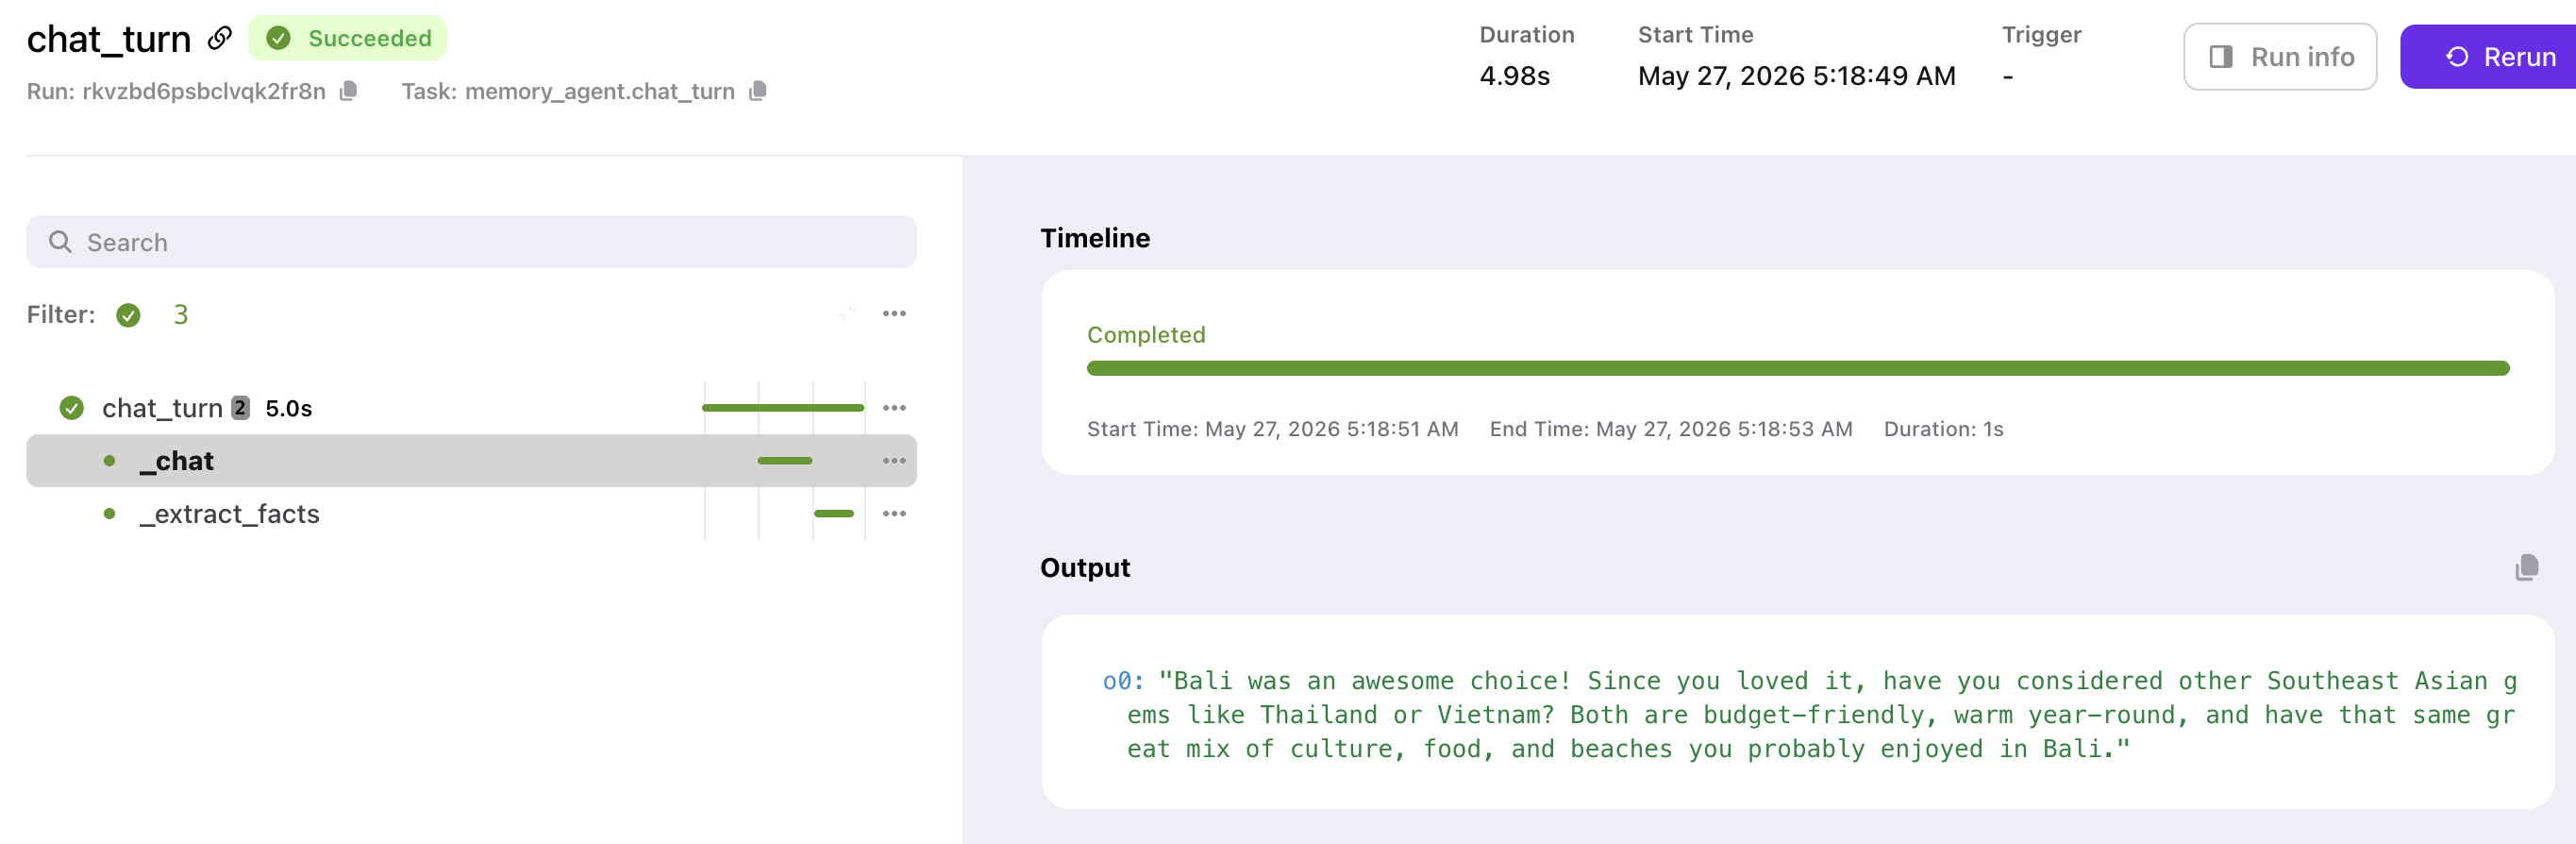

## Scaling the pattern

For high-throughput conversational systems, the `ReusePolicy` eliminates cold-start cost per turn. Each pod handles multiple concurrent conversations, with the `ConversationMemory` object passed in per-request rather than stored globally (no shared mutable state between requests).

> **Note:** `ReusePolicy` is a Union-specific feature that requires a [Union deployment](https://www.union.ai/docs/v2/union/). It is not supported on the local devbox.

In [ ]:
# Production: handle many concurrent chat sessions
production_memory_env = flyte.TaskEnvironment(
    name="memory_agent_prod",
    image=_image,
    resources=flyte.Resources(cpu="2", memory="4Gi"),
    secrets=[flyte.Secret(key="ANTHROPIC_API_KEY", as_env_var="ANTHROPIC_API_KEY")],
    reusable=flyte.ReusePolicy(
        replicas=(2, 8),
        concurrency=16,
        scaledown_ttl=timedelta(minutes=5),
        idle_ttl=timedelta(minutes=15),
    ),
)